# Sentiment Analysis LSTM + Evaluasi Detail + Visualisasi
Dataset: Instagram Comments (Bahasa Indonesia + Emoji)


In [17]:
!pip install pandas numpy scikit-learn tensorflow emoji matplotlib

In [18]:
import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional


## Load & Prepare Data

In [19]:
df = pd.read_csv('/content/Data_Gabungan.csv')
df = df[['Isi_Komentar','Sentimen']].dropna()

def map_label(x):
    if x == -1:
        return 0
    elif x == 0:
        return 1
    else:
        return 2

df['label_enc'] = df['Sentimen'].apply(map_label)


## Preprocessing

In [20]:
def clean_text(text):
    text = str(text).lower()
    text = emoji.demojize(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s:]', ' ', text)
    return text

df['clean'] = df['Isi_Komentar'].apply(clean_text)


## Tokenization

In [21]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean'])

seq = tokenizer.texts_to_sequences(df['clean'])
pad = pad_sequences(seq, maxlen=100, padding='post')


## Split Data

In [22]:
X_train, X_test, y_train, y_test = train_test_split(pad, df['label_enc'], test_size=0.2, random_state=42)

## Model BiLSTM

In [23]:
model = Sequential([
    Embedding(10000,128,input_length=100),
    Bidirectional(LSTM(128)),
    Dropout(0.5),
    Dense(64,activation='relu'),
    Dense(3,activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [24]:
history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.1)

Epoch 1/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 156s 381ms/step - accuracy: 0.6239 - loss: 0.8257 - val_accuracy: 0.7045 - val_loss: 0.7070
Epoch 2/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 137s 360ms/step - accuracy: 0.7602 - loss: 0.5883 - val_accuracy: 0.7097 - val_loss: 0.7370
Epoch 3/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 133s 348ms/step - accuracy: 0.8296 - loss: 0.4559 - val_accuracy: 0.6957 - val_loss: 0.7903
Epoch 4/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 133s 349ms/step - accuracy: 0.8675 - loss: 0.3560 - val_accuracy: 0.6890 - val_loss: 0.8889
Epoch 5/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 141s 347ms/step - accuracy: 0.8942 - loss: 0.2951 - val_accuracy: 0.6949 - val_loss: 1.0406
Epoch 6/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 132s 345ms/step - accuracy: 0.9066 - loss: 0.2589 - val_accuracy: 0.6802 - val_loss: 1.1366
Epoch 7/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 131s 343ms/step - accuracy: 0.9191 - loss: 0.2273 - val_accuracy: 0.6957 - val_loss: 1.2182
Epoch 8/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 133s 348ms/step - accuracy: 0.9304 -

## Evaluasi Detail

In [25]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print('Evaluasi pada data uji...')
cm = confusion_matrix(y_test, y_pred_classes)
print('Confusion Matrix:')
print(cm)

print('\nClassification Report:')
print(classification_report(y_test,y_pred_classes,target_names=['Negatif','Netral','Positif'],digits=4))

106/106 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step
Evaluasi pada data uji...
Confusion Matrix:
[[ 811  295  112]
 [ 288 1120  145]
 [ 111  122  388]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.6702    0.6658    0.6680      1218
      Netral     0.7287    0.7212    0.7249      1553
     Positif     0.6016    0.6248    0.6130       621

    accuracy                         0.6837      3392
   macro avg     0.6668    0.6706    0.6686      3392
weighted avg     0.6844    0.6837    0.6840      3392



## Hitung TP, FP, FN per kelas

In [26]:
for i, label in enumerate(['Negatif','Netral','Positif']):
    TP = cm[i][i]
    FP = cm[:,i].sum() - TP
    FN = cm[i,:].sum() - TP
    print(f'{label} -> TP:{TP}, FP:{FP}, FN:{FN}')

Negatif -> TP:811, FP:399, FN:407
Netral -> TP:1120, FP:417, FN:433
Positif -> TP:388, FP:257, FN:233


## Visualisasi Training

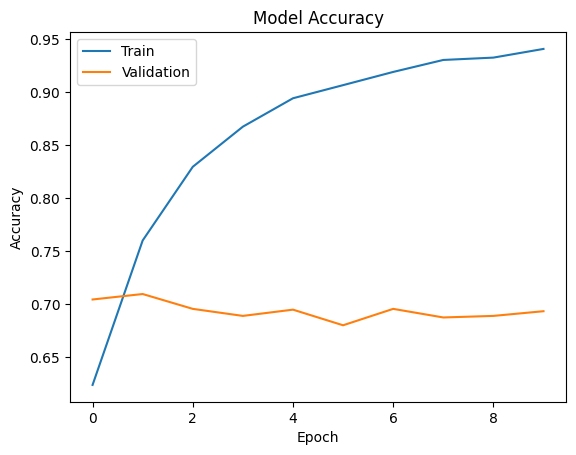

In [27]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

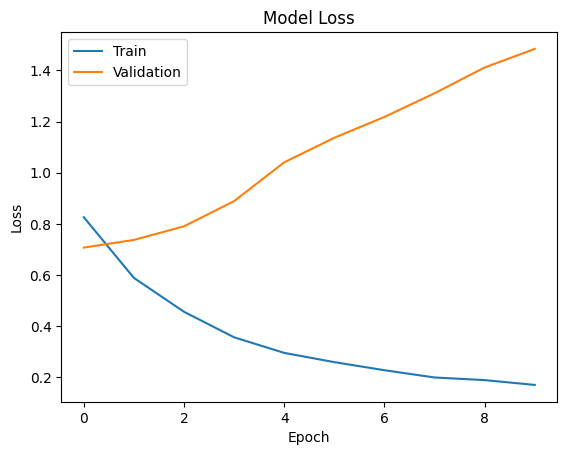

In [28]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()